---
# Machine learning : `spam` (Test)
---

## Packages

In [136]:
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.inspection import permutation_importance
from sklearn.metrics import mean_absolute_error, mean_absolute_percentage_error, mean_squared_error, accuracy_score, confusion_matrix, ConfusionMatrixDisplay
from sklearn.model_selection import GridSearchCV, train_test_split
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler

from sklearn.ensemble import HistGradientBoostingRegressor, RandomForestRegressor, RandomForestClassifier
from sklearn.svm import SVR
from sklearn.tree import DecisionTreeRegressor, DecisionTreeClassifier, plot_tree

import joblib
import time

## Configuration machine

Pour connaître le nombre de coeurs de sa machine :

In [103]:
n_cores = joblib.cpu_count(only_physical_cores=True)
print(f'Nombre de coeurs (physiques): {n_cores}')

Nombre de coeurs (physiques): 30


---
## 1. Données
---

### 1.1. Importation

In [104]:
# En local :
# directory = '/Users/vincentlefieux/Dropbox/Docs_ACADEMIQUE/Data/'

# Sur Google collab ou Onyxia (sur un répertoire temporaire) :
# directory = ''

# Sur Google collab (sur le drive) :
# from google.colab import drive
# drive.mount('/content/drive')
# directory = '/content/drive/MyDrive/Data/'

In [105]:
data = pd.read_csv('/home/onyxia/work/formation_cepe/Bloc3/data/spam.csv',
                   header    = 0,
                   sep       = ',')

In [106]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4601 entries, 0 to 4600
Data columns (total 58 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   word_freq_make              4601 non-null   float64
 1   word_freq_address           4601 non-null   float64
 2   word_freq_all               4601 non-null   float64
 3   word_freq_3d                4601 non-null   float64
 4   word_freq_our               4601 non-null   float64
 5   word_freq_over              4601 non-null   float64
 6   word_freq_remove            4601 non-null   float64
 7   word_freq_internet          4601 non-null   float64
 8   word_freq_order             4601 non-null   float64
 9   word_freq_mail              4601 non-null   float64
 10  word_freq_receive           4601 non-null   float64
 11  word_freq_will              4601 non-null   float64
 12  word_freq_people            4601 non-null   float64
 13  word_freq_report            4601 

In [107]:
data.head()

,word_freq_make,word_freq_address,word_freq_all,word_freq_3d,word_freq_our,word_freq_over,word_freq_remove,word_freq_internet,word_freq_order,word_freq_mail,...,char_freq_semicolon,char_freq_leftbrac,char_freq_leftsquarebrac,char_freq_exclaim,char_freq_dollar,char_freq_pound,capital_run_length_average,capital_run_length_longest,capital_run_length_total,spam
0,0.00,0.64,0.64,0.0,0.32,0.00,0.00,0.00,0.00,0.00,...,0.00,0.000,0.0,0.778,0.000,0.000,3.756,61,278,1
1,0.21,0.28,0.50,0.0,0.14,0.28,0.21,0.07,0.00,0.94,...,0.00,0.132,0.0,0.372,0.180,0.048,5.114,101,1028,1
2,0.06,0.00,0.71,0.0,1.23,0.19,0.19,0.12,0.64,0.25,...,0.01,0.143,0.0,0.276,0.184,0.010,9.821,485,2259,1
3,0.00,0.00,0.00,0.0,0.63,0.00,0.31,0.63,0.31,0.63,...,0.00,0.137,0.0,0.137,0.000,0.000,3.537,40,191,1
4,0.00,0.00,0.00,0.0,0.63,0.00,0.31,0.63,0.31,0.63,...,0.00,0.135,0.0,0.135,0.000,0.000,3.537,40,191,1


### 1.2. Gestion des données manquantes

In [108]:
missing_percentage = data.isna().mean() * 100

print('MISSING VALUES :')
if missing_percentage[missing_percentage != 0].empty:
    print('No')
else:
    print(missing_percentage[missing_percentage != 0].sort_values(ascending=False))

MISSING VALUES :
No


Vu que les données manquantes concernent essentiellement le pic d'ozone qu'on cherche à prédire, on retire les données manquantes ici :

In [109]:
data.dropna(inplace=True)

### 1.3. Gestion des variables

In [110]:
target = 'spam'
features = list(data.columns.difference([target]))

X = data[features]
y = data[target]

### 1.4. Création d'un échantillon test

In [111]:
test_portion = 1/5

X_train_valid, X_test, y_train_valid, y_test = train_test_split(X, y, test_size=test_portion)

print('Dimensions X_train_valid :', X_train_valid.shape)
print('Dimensions X_test        :', X_test.shape)
print('Dimensions y_train_valid :', y_train_valid.shape)
print('Dimensions y_test        :', y_test.shape)

Dimensions X_train_valid : (3680, 57)
Dimensions X_test        : (921, 57)
Dimensions y_train_valid : (3680,)
Dimensions y_test        : (921,)


---
## 2. Modélisation
---

In [112]:
criteria = 'neg_mean_squared_error' # Pour le choix du critère CV (-MSE)
n_folds  = 10                       # Pour le nombre de blocs CV (10)
n_core   = -1                       # Pour l'utilisation de tous les coeurs disponibles
verbose  = 1                        # Pour le caractère "verbeux"

### 2.1. CART

A titre purement illustratif, avec un "petit" arbre (profondeur maximale de 2) :

In [142]:
cart_model = DecisionTreeClassifier(max_depth=2)
cart = cart_model.fit(X_train_valid, y_train_valid)

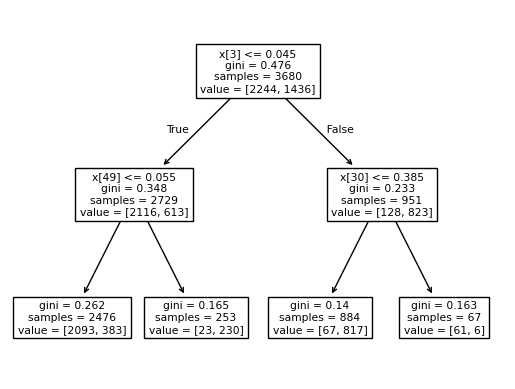

In [143]:
plot_tree(cart)
plt.show()

In [144]:
y_test_pred_cart = cart.predict(X_test)

In [145]:

score_cart = accuracy_score(y_test, y_test_pred_cart)
score_cart

0.8523344191096635

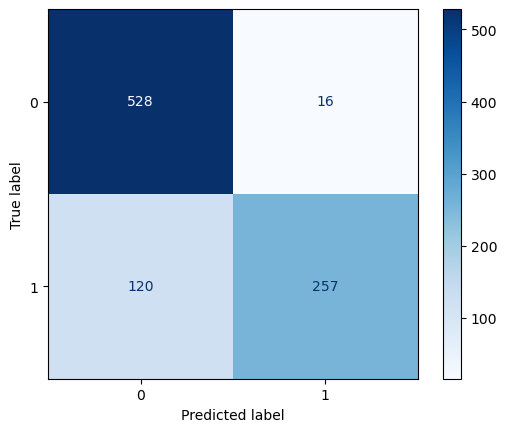

In [146]:
disp = ConfusionMatrixDisplay.from_estimator(
        cart,
        X_test,
        y_test,
        cmap=plt.cm.Blues
    )
plt.show()

Avec un "grand" arbre :

In [147]:
start_time = time.time()

In [148]:
cart_model = DecisionTreeClassifier()
cart = cart_model.fit(X_train_valid, y_train_valid)

In [149]:
y_test_pred_cart = cart.predict(X_test)

In [150]:
end_time = time.time()
execution_time_cart = end_time - start_time
print(f"Temps d'exécution CART : {execution_time_cart:.2f} secondes")

Temps d'exécution CART : 8.62 secondes


In [151]:
score_cart_model = accuracy_score(y_test, y_test_pred_cart)
score_cart_model

0.9239956568946797

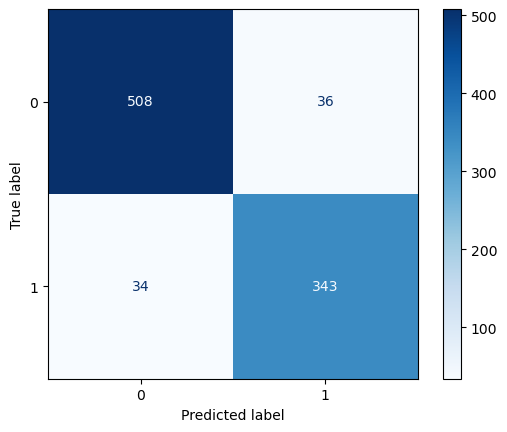

In [153]:
disp = ConfusionMatrixDisplay.from_estimator(
        cart,
        X_test,
        y_test,
        cmap=plt.cm.Blues
    )
plt.show()

### 2.2. Random forest

In [122]:
start_time = time.time()

In [123]:
rf_model = RandomForestClassifier()

params_rf = {
    'n_estimators': [200, 300, 400, 500]
}

rf = GridSearchCV(estimator  = rf_model,
                  param_grid = params_rf,
                  scoring    = criteria,
                  cv         = n_folds,
                  n_jobs     = n_core,
                  verbose    = verbose)

rf.fit(X_train_valid, y_train_valid)

Fitting 10 folds for each of 4 candidates, totalling 40 fits


GridSearchCV(cv=10, estimator=RandomForestClassifier(), n_jobs=-1,
             param_grid={'n_estimators': [200, 300, 400, 500]},
             scoring='neg_mean_squared_error', verbose=1)

In [124]:
y_test_pred_rf = rf.predict(X_test)

In [125]:
end_time = time.time()
execution_time_rf = end_time - start_time
print(f"Temps d'exécution Random forest : {execution_time_rf:.2f} secondes")

Temps d'exécution Random forest : 8.74 secondes


In [126]:
print('Hyperparamètre optimal Random forest :', rf.best_params_)

Hyperparamètre optimal Random forest : {'n_estimators': 400}


In [130]:
score_rf = accuracy_score(y_test, y_test_pred_rf)
score_rf

0.9478827361563518

In [135]:
confusion_matrix(y_test, y_test_pred_rf)

array([[531,  13],
       [ 35, 342]])

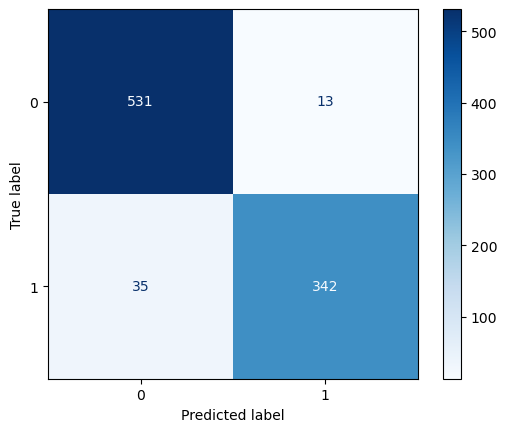

In [139]:
disp = ConfusionMatrixDisplay.from_estimator(
        rf,
        X_test,
        y_test,
        cmap=plt.cm.Blues
    )
plt.show()

On peut visualiser les résultats pour potentiellement réduire le nombre d'arbres choisi par validation croisée (si les performances sont proches) :

In [131]:
rf_out = pd.DataFrame(rf.cv_results_)
print(rf_out[['param_n_estimators', 'mean_test_score', 'std_test_score']])

   param_n_estimators  mean_test_score  std_test_score
0                 200        -0.048913        0.007491
1                 300        -0.050815        0.006662
2                 400        -0.048098        0.007974
3                 500        -0.049457        0.008043


On peut visualiser l'importance des variables :

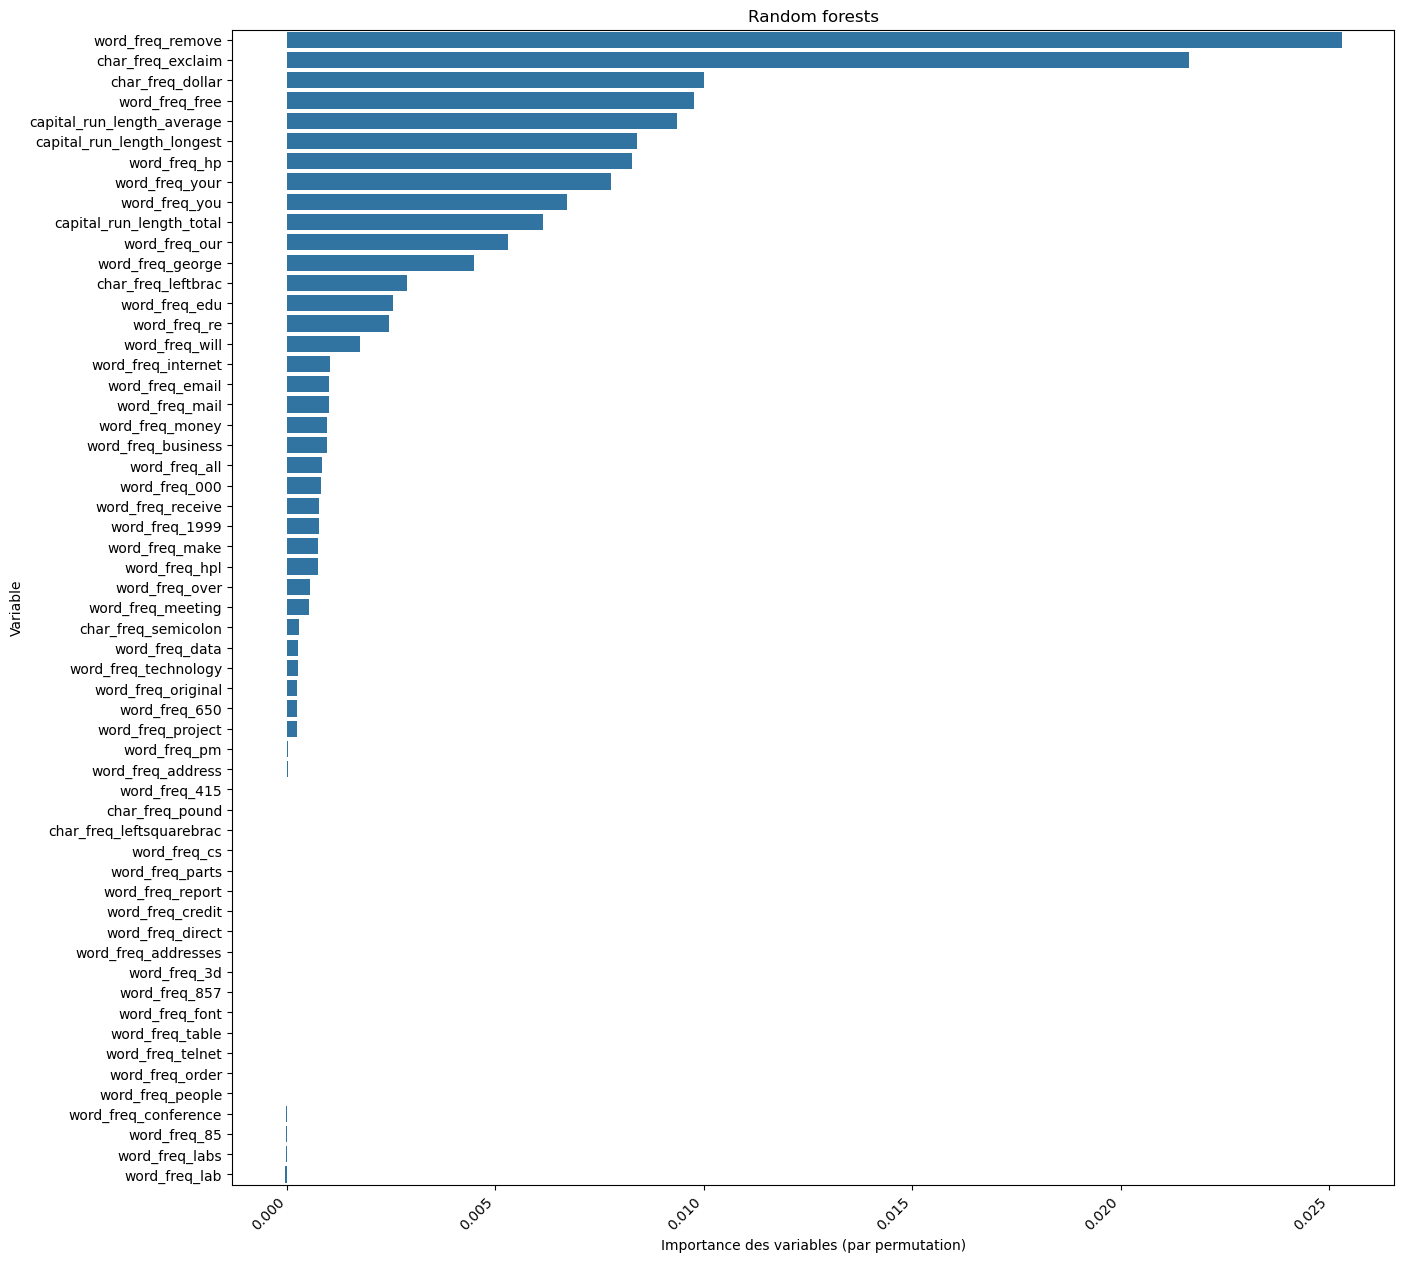

In [132]:
perm_importance_rf = permutation_importance(rf.best_estimator_, X_train_valid, y_train_valid, scoring=criteria, n_repeats=10, n_jobs=n_core)

perm_importance_df = pd.DataFrame({
    'Variable': X_train_valid.columns,
    'Importance': perm_importance_rf.importances_mean
    }).sort_values(by='Importance', ascending=False)

plt.figure(figsize=(15, 15))
sns.barplot(x='Importance', y='Variable', data=perm_importance_df)
plt.xticks(rotation=45, ha='right')
plt.xlabel('Importance des variables (par permutation)')
plt.ylabel('Variable')
plt.title('Random forests')
plt.show()